# Tarea 4
## Ejercicio 1

### Tlacaelel Jaime Flores Villaseñor

# Imports

In [28]:
import numpy as np
import os
from pathlib import Path
import hnswlib
import gc
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import joblib

# Carga de descriptores SIFT

In [29]:

def load_sift_descriptors(folder_path: str, split: str):
    """
    Carga descriptores SIFT organizados train  y test.
    """
    base_path = Path(folder_path) / split
    X = []  # Lista para almacenar matrices de descriptores por imagen
    y = []  # Etiquetas numéricas
    
    # Obtener nombres de las clases (carpetas dentro de train/test)
    classes = sorted([d.name for d in base_path.iterdir() if d.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(classes)}
    
    print(f"Cargando partición: {split}")
    
    for class_name in classes:
        
        features_dir = base_path / class_name / "features"
        
        if not features_dir.exists():
            print(f"Advertencia: No se encontró la carpeta features en {class_name}")
            continue
            
        # Iterar sobre los archivos .npy
        for npy_file in features_dir.glob("*.npy"):
            # Los descriptores SIFT son de 128 dimensiones
            descriptors = np.load(npy_file).astype(np.float32)
            X.append(descriptors)
            y.append(class_to_idx[class_name])
            
    return X, np.array(y), class_to_idx
            

In [30]:
X_train, y_train, mapping = load_sift_descriptors("data_tarea", "train")
X_test, y_test, _ = load_sift_descriptors("data_tarea", "test")

Cargando partición: train
Cargando partición: test


Tenemos  clases con 100 imagenes cada una en la carpeta de train, por lo que el tamaño de X train debe ser $15 \times 100 = 1500$

In [31]:
len(X_train)


1500

In [32]:
len(y_train)

1500

In [33]:
mapping

{'bedroom': 0,
 'coast': 1,
 'forest': 2,
 'highway': 3,
 'industrial': 4,
 'insidecity': 5,
 'kitchen': 6,
 'livingroom': 7,
 'mountain': 8,
 'office': 9,
 'opencountry': 10,
 'store': 11,
 'street': 12,
 'suburb': 13,
 'tallbuilding': 14}

In [34]:
def build_visual_vocabulary(data, k=10000, iterations=5):
    """
    Implementación de K-Means con HNSW.
    """
    n_samples, dim = data.shape
    
    print(f"Inicializando {k} centroides...")
    initial_indices = np.random.choice(n_samples, k, replace=False)
    centroids = data[initial_indices].copy()
    
    for i in range(iterations):
        print(f"Iteración {i+1}/{iterations} iniciada...")
        
        # Configuración del índice HNSW para los centroides
        # M: número de conexiones bidireccionales
        # ef_construction: tiempo/precisión en la construcción
        index = hnswlib.Index(space='l2', dim=dim)
        index.init_index(max_elements=k, ef_construction=200, M=16)
        index.add_items(centroids)
        index.set_ef(50) # Precisión en la búsqueda
        
        # Buscar el centroide más cercano para cada punto de data
        # labels: (n_samples, 1), contiene el índice del centroide asignado
        labels, _ = index.knn_query(data, k=1)
        labels = labels.flatten()
        
        # Mover los centroides al promedio de sus puntos asignados
        new_centroids = np.zeros_like(centroids)
        counts = np.zeros(k)
        
        # Vectorización parcial para calcular promedios
        for j in range(k):
            mask = (labels == j)
            if np.any(mask):
                new_centroids[j] = data[mask].mean(axis=0)
            else:
                # Si un centroide queda huérfano, se re-inicializa con un punto aleatorio
                new_centroids[j] = data[np.random.randint(n_samples)]
        
        centroids = new_centroids
        
        # Limpieza de memoria del índice en cada iteración
        del index
        gc.collect()
        
    return centroids

In [35]:
# Ejecución con la matriz concatenada de entrenamiento
X_train_stacked = np.vstack(X_train).astype(np.float32)
visual_vocabulary = build_visual_vocabulary(X_train_stacked)

Inicializando 10000 centroides...
Iteración 1/5 iniciada...
Iteración 2/5 iniciada...
Iteración 3/5 iniciada...
Iteración 4/5 iniciada...
Iteración 5/5 iniciada...


Guardar el vocabulario

In [36]:
np.save("visual_vocabulary_10k.npy", visual_vocabulary)

In [37]:
# LIBERAR MEMORIA
del X_train_stacked
gc.collect()


0

# Cuantización de Descriptores

definimos una función que transforme la lista de descriptores de cada imagen en un histograma de frecuencias.

In [38]:
# Leer el vocabulario visual desde el archivo guardado
visual_vocabulary = np.load("visual_vocabulary_10k.npy")

In [39]:
def compute_bof_histograms(X_list, vocabulary, k=10000):
    """
    Transforma listas de descriptores en histogramas de palabras visuales.
    """
    dim = vocabulary.shape[1]
    
    # Configurar índice HNSW para búsqueda rápida de vecinos
    index = hnswlib.Index(space='l2', dim=dim)
    index.init_index(max_elements=k, ef_construction=200, M=16)
    index.add_items(vocabulary)
    index.set_ef(50)
    
    histograms = []
    
    print(f"Procesando {len(X_list)} imágenes...")
    for descriptors in X_list:
        # Encontrar el centroide más cercano para cada descriptor de la imagen
        labels, _ = index.knn_query(descriptors.astype(np.float32), k=1)
        
        # Construir el histograma de frecuencias minlength asegura que el histograma siempre tenga tamaño 10,000
        counts = np.bincount(labels.flatten(), minlength=k)
        histograms.append(counts)
        
    return np.array(histograms, dtype=np.float32)

# Ejecución para ambos conjuntos
bof_train_raw = compute_bof_histograms(X_train, visual_vocabulary)
bof_test_raw = compute_bof_histograms(X_test, visual_vocabulary)

Procesando 1500 imágenes...
Procesando 2985 imágenes...


los histogramas deben ponderarse mediante tf-idf y normalizarse.  La ponderación $tf-idf$ para una palabra visual $w$ en una imagen $d$ se define como:$$tf\text{-}idf(w, d) = tf(w, d) \times \log\left(\frac{N}{df(w)}\right)$$
Donde $N$ es el número total de imágenes y $df(w)$ es el número de imágenes que contienen la palabra $w$.  

In [40]:
tfidf = TfidfTransformer(norm='l2', use_idf=True)

# Ajustar el transformador SOLO con los datos de entrenamiento
bof_train = tfidf.fit_transform(bof_train_raw).toarray()

# Aplicar a los datos de prueba
bof_test = tfidf.transform(bof_test_raw).toarray()

print(f"Forma final de la matriz de entrenamiento: {bof_train.shape}")

Forma final de la matriz de entrenamiento: (1500, 10000)


In [41]:
np.save("bof_train_final.npy", bof_train)
np.save("bof_test_final.npy", bof_test)

# Análisis para Descriptores SIFT

## Función para Reducir Descriptores SIFT
Esta función reduce la dimensionalidad intrínseca de los puntos de interés.

In [42]:
def reduce_sift_features(X_stacked, n_components, batch_size=2048)-> tuple[np.ndarray, IncrementalPCA]:
    """
    Reduce descriptores SIFT de 128 a n_components.
    Utiliza IncrementalPCA para manejar grandes volúmenes de datos sin cargar todo en memoria.
    Argumentos:
        - X_stacked: Matriz apilada de descriptores SIFT (n_samples, 128)
        - n_components: Número de componentes principales a conservar
        - batch_size: Tamaño del lote para el ajuste incremental
    Returns:
        - X_reduced: Matriz de descriptores reducidos (n_samples, n_components)
        - ipca: Modelo IncrementalPCA ajustado
    """
    ipca = IncrementalPCA(n_components=n_components)
    
    # Ajuste por lotes
    for i in range(0, X_stacked.shape[0], batch_size):
        ipca.partial_fit(X_stacked[i:i + batch_size])
        
    # Transformación
    X_reduced = ipca.transform(X_stacked)
    return X_reduced, ipca

## Función para Reducir Bolsas de Características


In [43]:
def reduce_bof_representation(bof_matrix, n_components, batch_size=200)-> tuple[np.ndarray, IncrementalPCA]:
    """
    Reduce histogramas de 10,000 a n_components.
    Utiliza IncrementalPCA para manejar grandes volúmenes de datos sin cargar todo en memoria.
    Argumentos:
        - bof_matrix: Matriz de histogramas BoF (n_samples, 10000)
        - n_components: Número de componentes principales a conservar
        - batch_size: Tamaño del lote para el ajuste incremental
    Returns:
        - bof_reduced: Matriz de histogramas reducidos (n_samples, n_components)
        - ipca: Modelo IncrementalPCA ajustado
    """
    ipca = IncrementalPCA(n_components=n_components)
    
    # Ajuste por lotes
    for i in range(0, bof_matrix.shape[0], batch_size):
        ipca.partial_fit(bof_matrix[i:i + batch_size])
        
    # Transformación
    bof_reduced = ipca.transform(bof_matrix)
    return bof_reduced, ipca

## Exploración de Varianza

In [44]:
def explorar_pca(data, nombre_dato, max_components, batch_size=500):
    """
    Grafica la varianza explicada acumulada para ayudar a la selección manual.
    """
    # Ajustar n_components al mínimo entre lo deseado y las dimensiones del dato
    n_comp = min(max_components, data.shape[1], data.shape[0])
    ipca = IncrementalPCA(n_components=n_comp)
    
    # partial_fit para eficiencia en memoria
    for i in range(0, data.shape[0], batch_size):
        ipca.partial_fit(data[i:i + batch_size])
    
    varianza_acumulada = np.cumsum(ipca.explained_variance_ratio_)

    # Encontrar el índice exacto para el 95%
    m_95 = np.argmax(varianza_acumulada >= 0.95) + 1

    # Encontrar el índice exacto para el 90%
    m_90 = np.argmax(varianza_acumulada >= 0.90) + 1

    print(f"Número exacto para 95% de varianza: {m_95}")
        
    # Graficación
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'b-')
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
    plt.axhline(y=0.90, color='g', linestyle='--', label='90% Varianza')
    
    plt.title(f"Análisis de Varianza Explicada: {nombre_dato}")
    plt.xlabel("Número de Componentes")
    plt.ylabel("Varianza Acumulada")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return varianza_acumulada

Número exacto para 95% de varianza: 1319


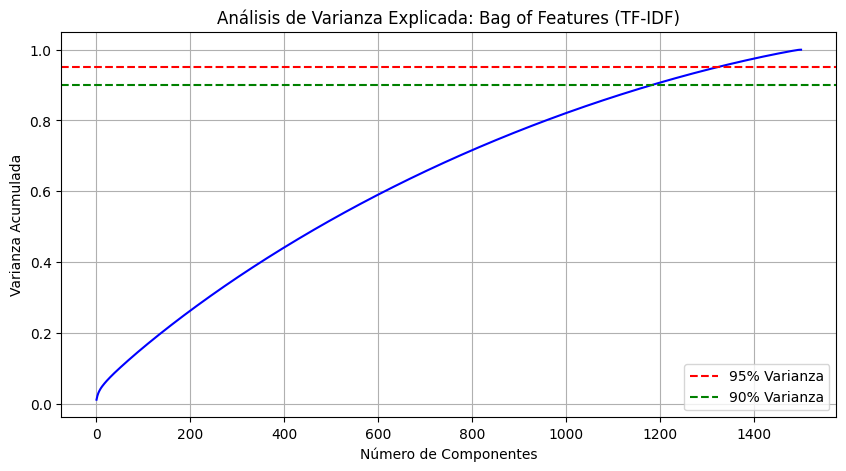

In [45]:
# Cargar las bolsas de entrenamiento
bof_train = np.load("bof_train_final.npy")

# Explorar los primeros 1000 componentes de las 10,000 dimensiones originales
varianza_bof = explorar_pca(bof_train, "Bag of Features (TF-IDF)", max_components=1499, batch_size=1500)

Número exacto para 95% de varianza: 74


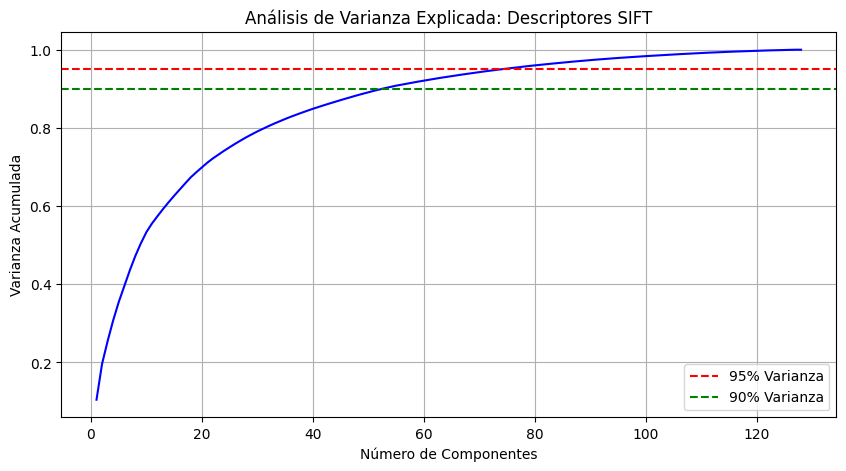

In [46]:
# Re-generar matriz de SIFT solo para el análisis de PCA
X_sift_temp = np.vstack(X_train).astype(np.float32)

# Explorar hasta los 128 componentes originales
varianza_sift = explorar_pca(X_sift_temp, "Descriptores SIFT", max_components=128)


# Entrenamientos

In [47]:
def train_and_persist_model(X_train, y_train, X_test, y_test, model_type, scenario_name)-> tuple[float, np.ndarray]:
    """
    Entrena, evalúa y guarda el modelo en disco.
    Argumentos:
        - X_train, y_train: Datos de entrenamiento
        - X_test, y_test: Datos de prueba
        - model_type: 'SVM' o 'RandomForest'
        - scenario_name: Nombre descriptivo para el escenario
    Retorna:
        - acc: Precisión del modelo en el conjunto de prueba
        - cm: Matriz de confusión del modelo en el conjunto de prueba
    """
    model_path = f"models/{model_type}_{scenario_name}.joblib"
    
    if not os.path.exists('models'):
        os.makedirs('models')

    if model_type == 'SVM':
        # C=1.0 y gamma='scale' son buenos puntos de partida para RBF
        clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    elif model_type == 'RandomForest':
        clf = RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
    
    print(f"Entrenando {model_type} para {scenario_name}...")
    clf.fit(X_train, y_train)
    
    # Persistencia
    joblib.dump(clf, model_path)
    print(f"Modelo guardado en: {model_path}")
    
    # Evaluación
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    return acc, cm

Procesaremos los datos según los valores de $n=74$ (SIFT) y $m=1319$ (BoF).

1. Usando los vectores de características originales.
2. Reduciendo las dimensiones de los vectores de características.
3. Reduciendo las bolsas de características.
4. Reduciendo tanto los vectores como las bolsas de características.

## Original

In [48]:
# X_train_bof y X_test_bof cargados de 'bof_train_final.npy'
acc_s1, cm_s1 = train_and_persist_model(bof_train, y_train, bof_test, y_test, 'SVM', 'original')
acc_rf_s1, cm_rf_s1 = train_and_persist_model(bof_train, y_train, bof_test, y_test, 'RandomForest', 'original')

Entrenando SVM para original...
Modelo guardado en: models/SVM_original.joblib
Entrenando RandomForest para original...
Modelo guardado en: models/RandomForest_original.joblib


## Bolsas reducidas

In [49]:
# Definir el número de componentes seleccionado en la exploración de PCA
m_final = 1319 

# Inicializar el modelo IncrementalPCA
ipca_bof = IncrementalPCA(n_components=m_final)

# Ajustar el modelo con los datos de entrenamiento (bof_train)
# El batch_size debe ser >= n_components para evitar el ValueError anterior
batch_size = 1500 
for i in range(0, bof_train.shape[0], batch_size):
    ipca_bof.partial_fit(bof_train[i:i + batch_size])

# Guardar el modelo PCA
joblib.dump(ipca_bof, "models/ipca_bof_1319.joblib")

['models/ipca_bof_1319.joblib']

In [50]:
# Transformar las bolsas de características de 10,000 a 1,319 dimensiones
X_train_m = ipca_bof.transform(bof_train)
X_test_m = ipca_bof.transform(bof_test)

# Verificar dimensiones resultantes
print(f"Nueva dimensión entrenamiento: {X_train_m.shape}") # Debe ser (1500, 1319)

# Entrenar y persistir el modelo del Escenario 3
acc_s3, cm_s3 = train_and_persist_model(X_train_m, y_train, X_test_m, y_test, 'SVM', 'bolsas_reducidas')
acc_rf_s3, cm_rf_s3 = train_and_persist_model(X_train_m, y_train, X_test_m, y_test, 'RandomForest', 'bolsas_reducidas')

Nueva dimensión entrenamiento: (1500, 1319)
Entrenando SVM para bolsas_reducidas...
Modelo guardado en: models/SVM_bolsas_reducidas.joblib
Entrenando RandomForest para bolsas_reducidas...
Modelo guardado en: models/RandomForest_bolsas_reducidas.joblib


## Reduccion dimensión de vectores

Para entrenar en este escenario es necesario modificar la naturaleza del vocabulario visual. A diferencia del escenario anterior, aquí la cuantización se realiza sobre un espacio de características ya reducido, de 128 a 74 dimensiones.

Este proceso requiere re-entrenar el índice HNSW, ya que los centroides deben existir en el mismo espacio vectorial que los descriptores reducidos.

Primero, ajustamos el modelo PCA sobre el total de descriptores de entrenamiento y transformamos tanto el conjunto de entrenamiento como el de prueba

In [51]:
# Preparar datos originales
X_train_stacked = np.vstack(X_train).astype(np.float32)

# Ajustar PCA incremental para descriptores SIFT
n_sift = 74
ipca_sift = IncrementalPCA(n_components=n_sift)

# Ajuste por lotes
batch_size_sift = 2048
for i in range(0, X_train_stacked.shape[0], batch_size_sift):
    ipca_sift.partial_fit(X_train_stacked[i:i + batch_size_sift])

# Transformar las listas de descriptores
X_train_red = [ipca_sift.transform(img.astype(np.float32)) for img in X_train]
X_test_red = [ipca_sift.transform(img.astype(np.float32)) for img in X_test]

# Crear la matriz apilada reducida para el vocabulario
X_train_stacked_red = np.vstack(X_train_red).astype(np.float32)

# Guardar modelo PCA de SIFT
joblib.dump(ipca_sift, "models/ipca_sift_74.joblib")

# Liberar memoria
del X_train_stacked
gc.collect()

9119

Con los descriptores ya en 74 dimensiones, generamos el nuevo vocabulario de 10,000 palabras.

In [52]:
# Entrenar vocabulario sobre descriptores de 74 dimensiones
vocab_s2 = build_visual_vocabulary(X_train_stacked_red, k=10000, iterations=5)


np.save("models/vocab_s2_10k.npy", vocab_s2)

del X_train_stacked_red
gc.collect()

Inicializando 10000 centroides...
Iteración 1/5 iniciada...
Iteración 2/5 iniciada...
Iteración 3/5 iniciada...
Iteración 4/5 iniciada...
Iteración 5/5 iniciada...


0

Utilizamos las listas reducidas X_train_red y X_test_red y el nuevo vocabulario para construir la representación final de este escenario.

In [53]:
# Cuantización  con descriptores de 74-dim
bof_train_s2_raw = compute_bof_histograms(X_train_red, vocab_s2)
bof_test_s2_raw = compute_bof_histograms(X_test_red, vocab_s2)

# Aplicar TF-IDF y Normalización L2
tfidf_s2 = TfidfTransformer(norm='l2', use_idf=True)
X_train_s2 = tfidf_s2.fit_transform(bof_train_s2_raw).toarray()
X_test_s2 = tfidf_s2.transform(bof_test_s2_raw).toarray()

# Persistencia de datos
np.save("X_train_s2.npy", X_train_s2)
np.save("X_test_s2.npy", X_test_s2)
joblib.dump(tfidf_s2, "models/tfidf_s2.joblib")

print(f"Listo. Dimensiones: {X_train_s2.shape}")

Procesando 1500 imágenes...
Procesando 2985 imágenes...
Listo. Dimensiones: (1500, 10000)


In [54]:
acc_s2, cm_s2 = train_and_persist_model(X_train_s2, y_train, X_test_s2, y_test, 'SVM', 'vectores_reducidos')
acc_rf_s2, cm_rf_s2 = train_and_persist_model(X_train_s2, y_train, X_test_s2, y_test, 'RandomForest', 'vectores_reducidos')


Entrenando SVM para vectores_reducidos...
Modelo guardado en: models/SVM_vectores_reducidos.joblib
Entrenando RandomForest para vectores_reducidos...
Modelo guardado en: models/RandomForest_vectores_reducidos.joblib


## Combinación

Dado que la distribución de las palabras visuales en el Escenario 2 es distinta a la del Escenario 1, el número de componentes para retener el 95% de la varianza en las bolsas de características puede variar de los 1,319 que encontramos previamente, por lo tanto volvemos a ejecuar la prueba 

Número exacto para 95% de varianza: 1320


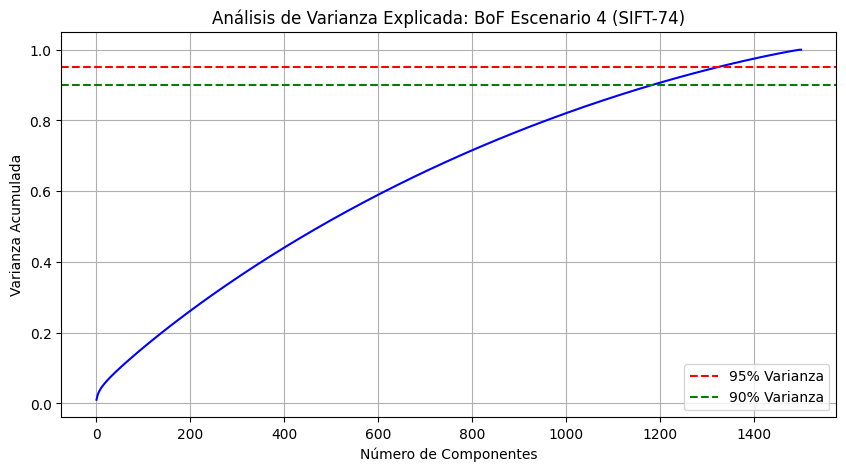

In [55]:
varianza_s4 = explorar_pca(X_train_s2, "BoF Escenario 4 (SIFT-74)", max_components=1499, batch_size=1500)

In [56]:
# Ajustar PCA incremental para las bolsas del escenario 2
ipca_s4 = IncrementalPCA(n_components=1320)

# Ajuste con lote completo para evitar errores de dimensiones
ipca_s4.partial_fit(X_train_s2)

# Transformación
X_train_s4 = ipca_s4.transform(X_train_s2)
X_test_s4 = ipca_s4.transform(X_test_s2)

joblib.dump(ipca_s4, "models/ipca_s4_final.joblib")

acc_svm_s4, cm_svm_s4 = train_and_persist_model(X_train_s4, y_train, X_test_s4, y_test, 'SVM', 'combinado')
acc_rf_s4, cm_rf_s4 = train_and_persist_model(X_train_s4, y_train, X_test_s4, y_test, 'RandomForest', 'combinado')

Entrenando SVM para combinado...
Modelo guardado en: models/SVM_combinado.joblib
Entrenando RandomForest para combinado...
Modelo guardado en: models/RandomForest_combinado.joblib
